# Backpropagation From Scratch —> Fitting a Sphere

In this notebook we build a tiny neural network **by hand**, using only NumPy, to fit points
sampled from the surface of a sphere. We will:

1. Generate a synthetic 3D dataset from the equation of a sphere.
2. Visualize it in 3D.
3. Build a small network (2 inputs → hidden layer → 1 output).
4. Walk through **one full epoch** manually:
   - Forward pass — first **algebraically** (neuron by neuron), then in **matrix form**.
   - Backward pass (backpropagation) — again algebraically, then in matrix form.
   - Weight update (gradient descent step).
5. Train the NumPy model for real over many epochs and plot the fitted surface.
6. Rebuild the exact same model in **PyTorch**, train it, and compare.

The goal is to demystify what `loss.backward()` and `optimizer.step()` are actually doing under the hood.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
%matplotlib inline

## 1. Create the sphere dataset

A sphere of radius $R$ centered at the origin satisfies:

$$x^2 + y^2 + z^2 = R^2$$

We'll treat $(x, y)$ as the **inputs** to our network and the **upper hemisphere** height

$$z = \sqrt{R^2 - x^2 - y^2}$$

as the **target** the network has to learn to predict. This gives us a simple, smooth,
non-linear regression surface


In [2]:
R = 5.0                     # radius of the sphere
n_samples = 300

# sample (x, y) uniformly inside the circle of radius R so that x^2 + y^2 <= R^2
angles = np.random.uniform(0, 2 * np.pi, n_samples)
radii = R * np.sqrt(np.random.uniform(0, 0.95, n_samples))  # keep away from the very edge
X_raw = np.stack([radii * np.cos(angles), radii * np.sin(angles)], axis=1)  # shape (N, 2)

# target: upper hemisphere height
Z_raw = np.sqrt(np.clip(R**2 - X_raw[:, 0]**2 - X_raw[:, 1]**2, 0, None))   # shape (N,)

print("X_raw shape:", X_raw.shape)
print("Z_raw shape:", Z_raw.shape)
print("First 5 rows of (x, y):\n", X_raw[:5])
print("First 5 targets z:\n", Z_raw[:5])

X_raw shape: (300, 2)
Z_raw shape: (300,)
First 5 rows of (x, y):
 [[-0.78113619  0.7856635 ]
 [ 3.38344296 -1.08258314]
 [-0.40453452 -3.56039829]
 [-3.16695447 -2.26038924]
 [ 2.31211675  3.4494616 ]]
First 5 targets z:
 [4.87571114 3.51856896 3.48710709 3.14022927 2.78483946]


### Normalize the data

Neural nets train much better when inputs/outputs are on a similar scale. We'll scale
everything by `R` so `x, y, z` all live roughly in `[-1, 1]`.

In [3]:
X = X_raw / R           # inputs, shape (N, 2), roughly in [-1, 1]
y = (Z_raw / R).reshape(-1, 1)   # targets, shape (N, 1), roughly in [0, 1]
print(X.shape, y.shape)

(300, 2) (300, 1)


## 2. Visualize the dataset in 3D

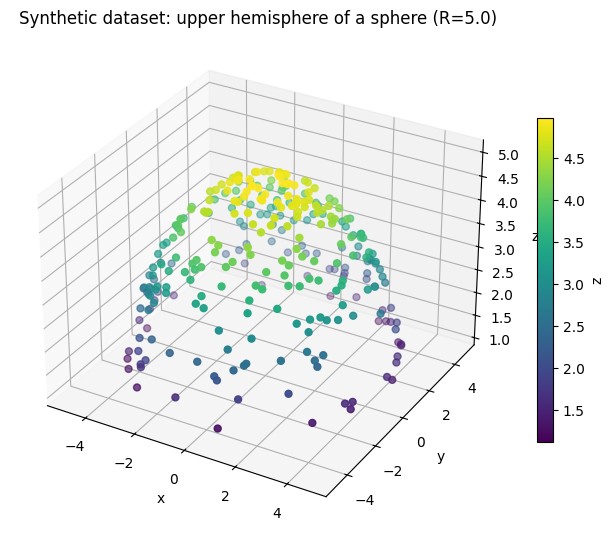

In [4]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_raw[:, 0], X_raw[:, 1], Z_raw, c=Z_raw, cmap='viridis', s=25)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(f'Synthetic dataset: upper hemisphere of a sphere (R={R})')
fig.colorbar(sc, ax=ax, shrink=0.6, label='z')
plt.show()

## 3. Define the network architecture

We'll use the smallest network that can do something interesting:

- **Input layer**: 2 units ($x$, $y$)
- **Hidden layer**: 3 units, `tanh` activation
- **Output layer**: 1 unit, linear activation (since we're doing regression)

Parameters:

- $W^{(1)}$: shape (2, 3), $b^{(1)}$: shape (3,)
- $W^{(2)}$: shape (3, 1), $b^{(2)}$: shape (1,)

We'll use **row-vector convention**: a single input sample $x$ is a $(1 \times 2)$ row vector, and
$x W^{(1)}$ gives a $(1 \times 3)$ row vector. This matches how NumPy/PyTorch batch data (rows = samples).

In [6]:
n_in, n_hidden, n_out = 2, 3, 1

# Small random initialization (fixed seed above -> reproducible)
W1 = np.random.randn(n_in, n_hidden) * 0.5      # (2, 3)
b1 = np.zeros((1, n_hidden))                    # (1, 3)
W2 = np.random.randn(n_hidden, n_out) * 0.5     # (3, 1)
b2 = np.zeros((1, n_out))                       # (1, 1)

print("W1 =\n", W1)
print("==============x=====================x============")
print("b1 =", b1)
print("==============x=====================x============")
print("W2 =\n", W2)
print("==============x=====================x============")
print("b2 =", b2)

W1 =
 [[ 0.10698996 -0.05616402 -0.1104848 ]
 [ 0.30708335  0.37875386 -0.26525057]]
==============x=====================x============
b1 = [[0. 0. 0.]]
==============x=====================x============
W2 =
 [[-0.28790912]
 [-0.13752585]
 [-1.15096058]]
==============x=====================x============
b2 = [[0.]]


## 4. One full epoch, done manually

To keep the algebra readable we'll manually walk through the math using **a single training
example** first (so every quantity is just a number), and then immediately show the exact same
computation **in matrix form** using NumPy so you can see how it generalizes to a whole batch.

Let's grab sample #0 from our dataset.

In [7]:
x_sample = X[0:1, :]     # shape (1, 2) -- keep it 2D so matrix ops line up
y_sample = y[0:1, :]     # shape (1, 1)

x1, x2 = x_sample[0]
y_true = y_sample[0, 0]

print(f"(x1 = {x1:.4f}, x2 = {x2:.4f})")
print(f"y_true = {y_true:.4f}")

(x1 = -0.1562, x2 = 0.1571)
y_true = 0.9751


### 4a. Forward pass — algebraic (neuron by neuron)

**Hidden layer.** Each hidden neuron $j \in \{1, 2, 3\}$ computes a weighted sum of the inputs,
then squashes it with $\tanh$:

$$z^{(1)}_j = x_1 w^{(1)}_{1j} + x_2 w^{(1)}_{2j} + b^{(1)}_j$$
$$a^{(1)}_j = \tanh\left(z^{(1)}_j\right)$$

**Output layer.** The single output neuron combines the 3 hidden activations linearly:

$$\hat{y} = a^{(1)}_1 w^{(2)}_1 + a^{(1)}_2 w^{(2)}_2 + a^{(1)}_3 w^{(2)}_3 + b^{(2)}$$

**Loss.** We use squared error for this one example:

$$L = \frac{1}{2}\left(\hat{y} - y\right)^2$$

Let's compute each of these by hand, one neuron at a time.


In [8]:
print("---- Hidden layer (algebraic, neuron by neuron) ----")
z1_manual = np.zeros(n_hidden)
a1_manual = np.zeros(n_hidden)
for j in range(n_hidden):
    z1_manual[j] = x1 * W1[0, j] + x2 * W1[1, j] + b1[0, j]
    a1_manual[j] = np.tanh(z1_manual[j])
    print(f"  neuron {j}: z1_{j} = {z1_manual[j]:.5f}  ->  a1_{j} = tanh(z1_{j}) = {a1_manual[j]:.5f}")

print("\n---- Output layer (algebraic) ----")
y_hat_manual = b2[0, 0]
for j in range(n_hidden):
    contribution = a1_manual[j] * W2[j, 0]
    y_hat_manual += contribution
    print(f"  a1_{j} * w2_{j} = {a1_manual[j]:.5f} * {W2[j,0]:.5f} = {contribution:.5f}")
print(f"  y_hat = sum(contributions) + b2 = {y_hat_manual:.5f}")

loss_manual = 0.5 * (y_hat_manual - y_true) ** 2
print(f"\nLoss L = 0.5 * (y_hat - y_true)^2 = 0.5 * ({y_hat_manual:.5f} - {y_true:.5f})^2 = {loss_manual:.6f}")

---- Hidden layer (algebraic, neuron by neuron) ----
  neuron 0: z1_0 = 0.03154  ->  a1_0 = tanh(z1_0) = 0.03153
  neuron 1: z1_1 = 0.06829  ->  a1_1 = tanh(z1_1) = 0.06818
  neuron 2: z1_2 = -0.02442  ->  a1_2 = tanh(z1_2) = -0.02441

---- Output layer (algebraic) ----
  a1_0 * w2_0 = 0.03153 * -0.28791 = -0.00908
  a1_1 * w2_1 = 0.06818 * -0.13753 = -0.00938
  a1_2 * w2_2 = -0.02441 * -1.15096 = 0.02810
  y_hat = sum(contributions) + b2 = 0.00965

Loss L = 0.5 * (y_hat - y_true)^2 = 0.5 * (0.00965 - 0.97514)^2 = 0.466092


### 4b. Forward pass — matrix form (NumPy)

The exact same computation, expressed as matrix multiplications. This is what lets us process
a whole batch of samples at once instead of looping neuron-by-neuron:

$$Z^{(1)} = X W^{(1)} + b^{(1)} \qquad A^{(1)} = \tanh\left(Z^{(1)}\right)$$
$$\hat{Y} = A^{(1)} W^{(2)} + b^{(2)}$$
$$L = \frac{1}{2}\left(\hat{Y} - Y\right)^2$$

Let's verify it reproduces the exact same numbers as the manual version above (for our one sample).


In [9]:
Z1 = x_sample @ W1 + b1        # (1,2)@(2,3) + (1,3) -> (1,3)
A1 = np.tanh(Z1)                # (1,3)
y_hat = A1 @ W2 + b2            # (1,3)@(3,1) + (1,1) -> (1,1)
loss = 0.5 * (y_hat - y_sample) ** 2

print("Z1 (matrix form)      =", Z1)
print("z1 (manual, neuron)   =", z1_manual)
print()
print("A1 (matrix form)      =", A1)
print("a1 (manual, neuron)   =", a1_manual)
print()
print("y_hat (matrix form)   =", y_hat.ravel())
print("y_hat (manual)        =", y_hat_manual)
print()
print("loss (matrix form)    =", loss.ravel())
print("loss (manual)         =", loss_manual)

Z1 (matrix form)      = [[ 0.03153809  0.06828897 -0.0244188 ]]
z1 (manual, neuron)   = [ 0.03153809  0.06828897 -0.0244188 ]

A1 (matrix form)      = [[ 0.03152764  0.06818301 -0.02441395]]
a1 (manual, neuron)   = [ 0.03152764  0.06818301 -0.02441395]

y_hat (matrix form)   = [0.00964547]
y_hat (manual)        = 0.009645474566525997

loss (matrix form)    = [0.46609199]
loss (manual)         = 0.4660919904754969


### 4c. Backward pass — algebraic (the chain rule, neuron by neuron)

Now the interesting part: computing how much each weight contributed to the loss, using the
**chain rule**, one derivative at a time.

**Step 1 — gradient of the loss w.r.t. the prediction:**
$$\frac{\partial L}{\partial \hat{y}} = (\hat{y} - y)$$

**Step 2 — gradients for the output layer** ($\hat{y}$ is a linear function of $a^{(1)}_j$, so the
derivative just passes through):
$$\frac{\partial L}{\partial w^{(2)}_j} = \frac{\partial L}{\partial \hat{y}} \cdot a^{(1)}_j
\qquad\qquad
\frac{\partial L}{\partial b^{(2)}} = \frac{\partial L}{\partial \hat{y}}$$

**Step 3 — gradient flowing back into each hidden neuron.** We need $\frac{\partial L}{\partial a^{(1)}_j}$,
then multiply by the local derivative of $\tanh$ (recall $\tanh'(z) = 1 - \tanh(z)^2$):
$$\frac{\partial L}{\partial a^{(1)}_j} = \frac{\partial L}{\partial \hat{y}} \cdot w^{(2)}_j
\qquad\qquad
\frac{\partial L}{\partial z^{(1)}_j} = \frac{\partial L}{\partial a^{(1)}_j} \cdot \left(1 - \left(a^{(1)}_j\right)^2\right)$$

**Step 4 — gradients for the hidden layer weights:**
$$\frac{\partial L}{\partial w^{(1)}_{ij}} = \frac{\partial L}{\partial z^{(1)}_j} \cdot x_i
\qquad\qquad
\frac{\partial L}{\partial b^{(1)}_j} = \frac{\partial L}{\partial z^{(1)}_j}$$

Let's compute every single one of these numbers explicitly.


In [10]:
print("---- Step 1: dL/dy_hat ----")
dL_dyhat = (y_hat_manual - y_true)
print(f"  dL/dy_hat = y_hat - y_true = {y_hat_manual:.5f} - {y_true:.5f} = {dL_dyhat:.5f}")

print("\n---- Step 2: output layer gradients ----")
dL_dW2_manual = np.zeros(n_hidden)
for j in range(n_hidden):
    dL_dW2_manual[j] = dL_dyhat * a1_manual[j]
    print(f"  dL/dw2_{j} = dL/dy_hat * a1_{j} = {dL_dyhat:.5f} * {a1_manual[j]:.5f} = {dL_dW2_manual[j]:.5f}")
dL_db2_manual = dL_dyhat
print(f"  dL/db2 = dL/dy_hat = {dL_db2_manual:.5f}")

print("\n---- Step 3: gradient flowing back into hidden neurons ----")
dL_da1_manual = np.zeros(n_hidden)
dL_dz1_manual = np.zeros(n_hidden)
for j in range(n_hidden):
    dL_da1_manual[j] = dL_dyhat * W2[j, 0]
    tanh_deriv = 1 - a1_manual[j] ** 2
    dL_dz1_manual[j] = dL_da1_manual[j] * tanh_deriv
    print(f"  neuron {j}: dL/da1_{j} = {dL_dyhat:.5f} * {W2[j,0]:.5f} = {dL_da1_manual[j]:.5f}"
          f"   |   tanh'(z1_{j}) = 1 - a1_{j}^2 = {tanh_deriv:.5f}"
          f"   |   dL/dz1_{j} = {dL_dz1_manual[j]:.5f}")

print("\n---- Step 4: hidden layer weight gradients ----")
dL_dW1_manual = np.zeros((n_in, n_hidden))
for i, x_i in enumerate([x1, x2]):
    for j in range(n_hidden):
        dL_dW1_manual[i, j] = dL_dz1_manual[j] * x_i
        print(f"  dL/dw1_{i}{j} = dL/dz1_{j} * x_{i} = {dL_dz1_manual[j]:.5f} * {x_i:.5f} = {dL_dW1_manual[i,j]:.5f}")
dL_db1_manual = dL_dz1_manual.copy()
print("\n  dL/db1 =", dL_db1_manual)

---- Step 1: dL/dy_hat ----
  dL/dy_hat = y_hat - y_true = 0.00965 - 0.97514 = -0.96550

---- Step 2: output layer gradients ----
  dL/dw2_0 = dL/dy_hat * a1_0 = -0.96550 * 0.03153 = -0.03044
  dL/dw2_1 = dL/dy_hat * a1_1 = -0.96550 * 0.06818 = -0.06583
  dL/dw2_2 = dL/dy_hat * a1_2 = -0.96550 * -0.02441 = 0.02357
  dL/db2 = dL/dy_hat = -0.96550

---- Step 3: gradient flowing back into hidden neurons ----
  neuron 0: dL/da1_0 = -0.96550 * -0.28791 = 0.27798   |   tanh'(z1_0) = 1 - a1_0^2 = 0.99901   |   dL/dz1_0 = 0.27770
  neuron 1: dL/da1_1 = -0.96550 * -0.13753 = 0.13278   |   tanh'(z1_1) = 1 - a1_1^2 = 0.99535   |   dL/dz1_1 = 0.13216
  neuron 2: dL/da1_2 = -0.96550 * -1.15096 = 1.11125   |   tanh'(z1_2) = 1 - a1_2^2 = 0.99940   |   dL/dz1_2 = 1.11059

---- Step 4: hidden layer weight gradients ----
  dL/dw1_00 = dL/dz1_0 * x_0 = 0.27770 * -0.15623 = -0.04338
  dL/dw1_01 = dL/dz1_1 * x_0 = 0.13216 * -0.15623 = -0.02065
  dL/dw1_02 = dL/dz1_2 * x_0 = 1.11059 * -0.15623 = -0.17350
  

### 4d. Backward pass — matrix form (NumPy)

The exact same chain rule, expressed compactly with matrix operations:

$$\frac{\partial L}{\partial \hat{Y}} = \left(\hat{Y} - Y\right)$$

$$\frac{\partial L}{\partial W^{(2)}} = {A^{(1)}}^{T} \cdot \frac{\partial L}{\partial \hat{Y}}
\qquad
\frac{\partial L}{\partial b^{(2)}} = \sum \frac{\partial L}{\partial \hat{Y}}$$

$$\frac{\partial L}{\partial A^{(1)}} = \frac{\partial L}{\partial \hat{Y}} \cdot {W^{(2)}}^{T}
\qquad
\frac{\partial L}{\partial Z^{(1)}} = \frac{\partial L}{\partial A^{(1)}} \odot \left(1 - \left(A^{(1)}\right)^2\right)$$

$$\frac{\partial L}{\partial W^{(1)}} = X^{T} \cdot \frac{\partial L}{\partial Z^{(1)}}
\qquad
\frac{\partial L}{\partial b^{(1)}} = \sum \frac{\partial L}{\partial Z^{(1)}}$$

(The sums over the batch dimension collapse to nothing when we only have 1 sample, which is
why they match the scalars from the manual version.)


In [11]:
dL_dyhat_mat = (y_hat - y_sample)              # (1,1)

dL_dW2 = A1.T @ dL_dyhat_mat                     # (3,1)@... -> (3,1)
dL_db2 = dL_dyhat_mat.sum(axis=0, keepdims=True) # (1,1)

dL_dA1 = dL_dyhat_mat @ W2.T                     # (1,1)@(1,3) -> (1,3)
dL_dZ1 = dL_dA1 * (1 - A1 ** 2)                  # (1,3)

dL_dW1 = x_sample.T @ dL_dZ1                     # (2,1)@(1,3) -> (2,3)
dL_db1 = dL_dZ1.sum(axis=0, keepdims=True)       # (1,3)

print("dL_dW2 (matrix) =", dL_dW2.ravel(), "  |  (manual) =", dL_dW2_manual)
print("dL_db2 (matrix) =", dL_db2.ravel(), "  |  (manual) =", dL_db2_manual)
print("dL_dW1 (matrix) =\n", dL_dW1, "\n(manual) =\n", dL_dW1_manual)
print("dL_db1 (matrix) =", dL_db1.ravel(), "  |  (manual) =", dL_db1_manual)


dL_dW2 (matrix) = [-0.03043983 -0.06583048  0.02357159]   |  (manual) = [-0.03043983 -0.06583048  0.02357159]
dL_db2 (matrix) = [-0.96549675]   |  (manual) = -0.9654967534647612
dL_dW1 (matrix) =
 [[-0.04338415 -0.02064753 -0.17350384]
 [ 0.0436356   0.0207672   0.17450943]] 
(manual) =
 [[-0.04338415 -0.02064753 -0.17350384]
 [ 0.0436356   0.0207672   0.17450943]]
dL_db1 (matrix) = [0.27769902 0.13216347 1.11058636]   |  (manual) = [0.27769902 0.13216347 1.11058636]


### 4e. Update the weights (gradient descent step)

Finally, we nudge every parameter a small step in the direction that reduces the loss:

$$W \leftarrow W - \eta \frac{\partial L}{\partial W} \qquad b \leftarrow b - \eta \frac{\partial L}{\partial b}$$

where $\eta$ is the **learning rate**.


In [12]:
lr = 0.1

print("Before update:")
print(" W1 =\n", W1)
print(" W2 =\n", W2)

W1 = W1 - lr * dL_dW1
b1 = b1 - lr * dL_db1
W2 = W2 - lr * dL_dW2
b2 = b2 - lr * dL_db2

print("==============x=====================x============")
print("\nAfter ONE manual training step (using just 1 sample):")
print(" W1 =\n", W1)
print(" W2 =\n", W2)

# quick sanity check: loss should have gone down for this sample
Z1_new = x_sample @ W1 + b1
A1_new = np.tanh(Z1_new)
y_hat_new = A1_new @ W2 + b2
loss_new = 0.5 * (y_hat_new - y_sample) ** 2
print(f"\nLoss before update: {loss[0,0]:.6f}")
print(f"Loss after update:  {loss_new[0,0]:.6f}")


Before update:
 W1 =
 [[ 0.10698996 -0.05616402 -0.1104848 ]
 [ 0.30708335  0.37875386 -0.26525057]]
 W2 =
 [[-0.28790912]
 [-0.13752585]
 [-1.15096058]]
==============x=====================x============

After ONE manual training step (using just 1 sample):
 W1 =
 [[ 0.11132837 -0.05409927 -0.09313442]
 [ 0.30271979  0.37667713 -0.28270152]]
 W2 =
 [[-0.28486514]
 [-0.1309428 ]
 [-1.15331774]]

Loss before update: 0.466092
Loss after update:  0.262760


That single step already reduced the loss for this example — that's backpropagation +
gradient descent working exactly as intended, computed entirely by hand.

## 5. Now train for real (full batch, many epochs, pure NumPy)

Let's package the forward/backward logic into reusable functions and train on the **whole
dataset** for many epochs, using batch (matrix) computations throughout.


In [13]:
def init_params(seed=0):
    rng = np.random.RandomState(seed)
    W1 = rng.randn(n_in, n_hidden) * 0.5
    b1 = np.zeros((1, n_hidden))
    W2 = rng.randn(n_hidden, n_out) * 0.5
    b2 = np.zeros((1, n_out))
    return W1, b1, W2, b2

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = np.tanh(Z1)
    Y_hat = A1 @ W2 + b2
    cache = (X, Z1, A1)
    return Y_hat, cache

def backward(Y_hat, Y, W2, cache):
    X, Z1, A1 = cache
    n = X.shape[0]
    dL_dYhat = (Y_hat - Y) / n                 # average over the batch
    dW2 = A1.T @ dL_dYhat
    db2 = dL_dYhat.sum(axis=0, keepdims=True)
    dA1 = dL_dYhat @ W2.T
    dZ1 = dA1 * (1 - A1 ** 2)
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2

def mse(Y_hat, Y):
    return np.mean(0.5 * (Y_hat - Y) ** 2)

W1, b1, W2, b2 = init_params(seed=0)
lr = 0.5
n_epochs = 3000
losses = []

for epoch in range(n_epochs):
    Y_hat, cache = forward(X, W1, b1, W2, b2)
    loss = mse(Y_hat, y)
    losses.append(loss)

    dW1, db1, dW2, db2 = backward(Y_hat, y, W2, cache)
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if epoch % 500 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:5d}  |  loss {loss:.6f}")

epoch     0  |  loss 0.281381
epoch   500  |  loss 0.007467
epoch  1000  |  loss 0.001660
epoch  1500  |  loss 0.001518
epoch  2000  |  loss 0.001462
epoch  2500  |  loss 0.001419
epoch  2999  |  loss 0.001383


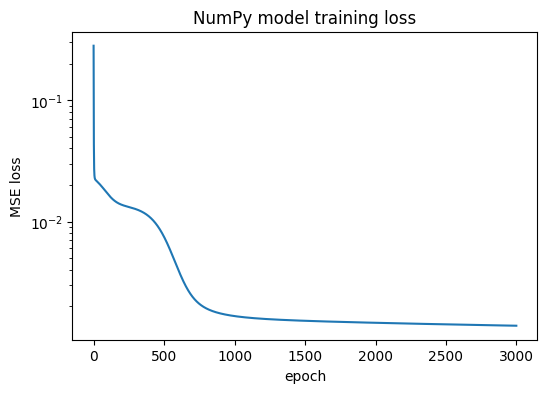

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("NumPy model training loss")
plt.yscale("log")
plt.show()

## 6. Plot the fitted surface vs. the original sphere

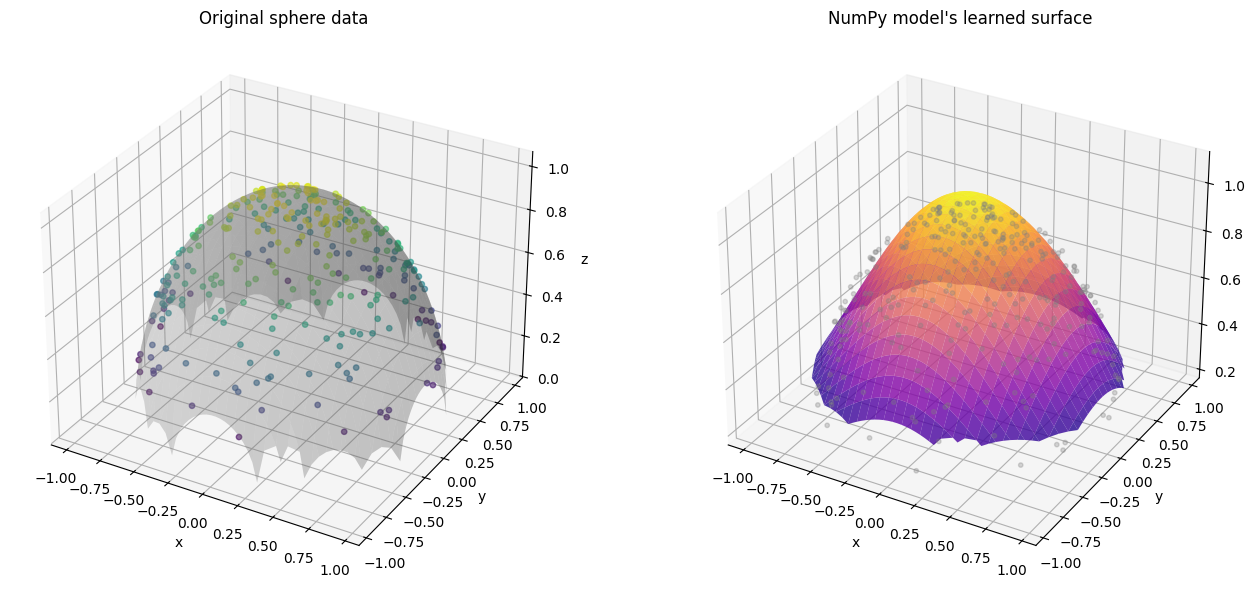

In [15]:
grid_n = 60
lin = np.linspace(-0.95, 0.95, grid_n)
gx, gy = np.meshgrid(lin, lin)
grid_X = np.stack([gx.ravel(), gy.ravel()], axis=1)

mask = (grid_X[:, 0] ** 2 + grid_X[:, 1] ** 2) <= 1.0

grid_Yhat, _ = forward(grid_X, W1, b1, W2, b2)
grid_Yhat = grid_Yhat.ravel()
grid_Yhat[~mask] = np.nan
gz_pred = grid_Yhat.reshape(grid_n, grid_n)

grid_Ztrue = np.sqrt(np.clip(1 - grid_X[:, 0] ** 2 - grid_X[:, 1] ** 2, 0, None))
grid_Ztrue[~mask] = np.nan
gz_true = grid_Ztrue.reshape(grid_n, grid_n)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], y[:, 0], c=y[:, 0], cmap='viridis', s=15, alpha=0.6)
ax1.plot_surface(gx, gy, gz_true, alpha=0.3, color='gray')
ax1.set_title("Original sphere data")
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X[:, 0], X[:, 1], y[:, 0], c='gray', s=10, alpha=0.3, label='true data')
ax2.plot_surface(gx, gy, gz_pred, cmap='plasma', alpha=0.8)
ax2.set_title("NumPy model's learned surface")
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

plt.tight_layout()
plt.show()

## 7. The same model in PyTorch

Now let's rebuild the identical architecture (2 → 3 tanh → 1) in PyTorch and let autograd +
an optimizer handle the forward/backward/update steps we just did by hand.


In [16]:
import torch
import torch.nn as nn

torch.manual_seed(0)

class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 3)
        self.output = nn.Linear(3, 1)

    def forward(self, x):
        a1 = torch.tanh(self.hidden(x))
        return self.output(a1)

model = NeuralNet()
print(model)

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

criterion = nn.MSELoss()
# NOTE: nn.MSELoss returns mean((y_hat - y)^2), while our from-scratch loss used mean(0.5*(y_hat-y)^2).
# We scale the loss by 0.5 so training dynamics match our manual version above.
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

torch_losses = []
n_epochs_torch = 3000

for epoch in range(n_epochs_torch):
    optimizer.zero_grad()
    y_hat_t = model(X_t)
    loss_t = 0.5 * criterion(y_hat_t, y_t)
    loss_t.backward()
    optimizer.step()
    torch_losses.append(loss_t.item())

    if epoch % 500 == 0 or epoch == n_epochs_torch - 1:
        print(f"epoch {epoch:5d}  |  loss {loss_t.item():.6f}")

NeuralNet(
  (hidden): Linear(in_features=2, out_features=3, bias=True)
  (output): Linear(in_features=3, out_features=1, bias=True)
)
epoch     0  |  loss 0.882166
epoch   500  |  loss 0.005515
epoch  1000  |  loss 0.001518
epoch  1500  |  loss 0.001383
epoch  2000  |  loss 0.001341
epoch  2500  |  loss 0.001312
epoch  2999  |  loss 0.001288


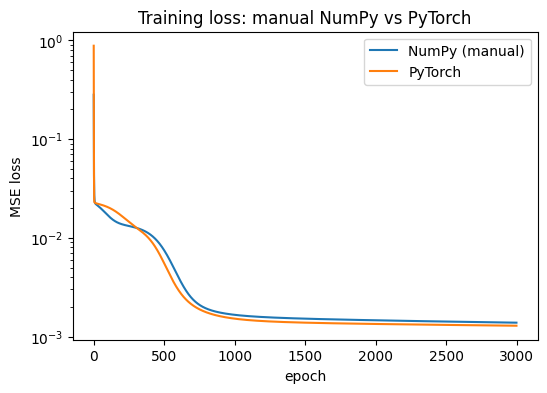

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(losses, label="NumPy (manual)")
plt.plot(torch_losses, label="PyTorch")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.yscale("log")
plt.legend()
plt.title("Training loss: manual NumPy vs PyTorch")
plt.show()

## 8. Compare all three: original sphere, NumPy model, PyTorch model

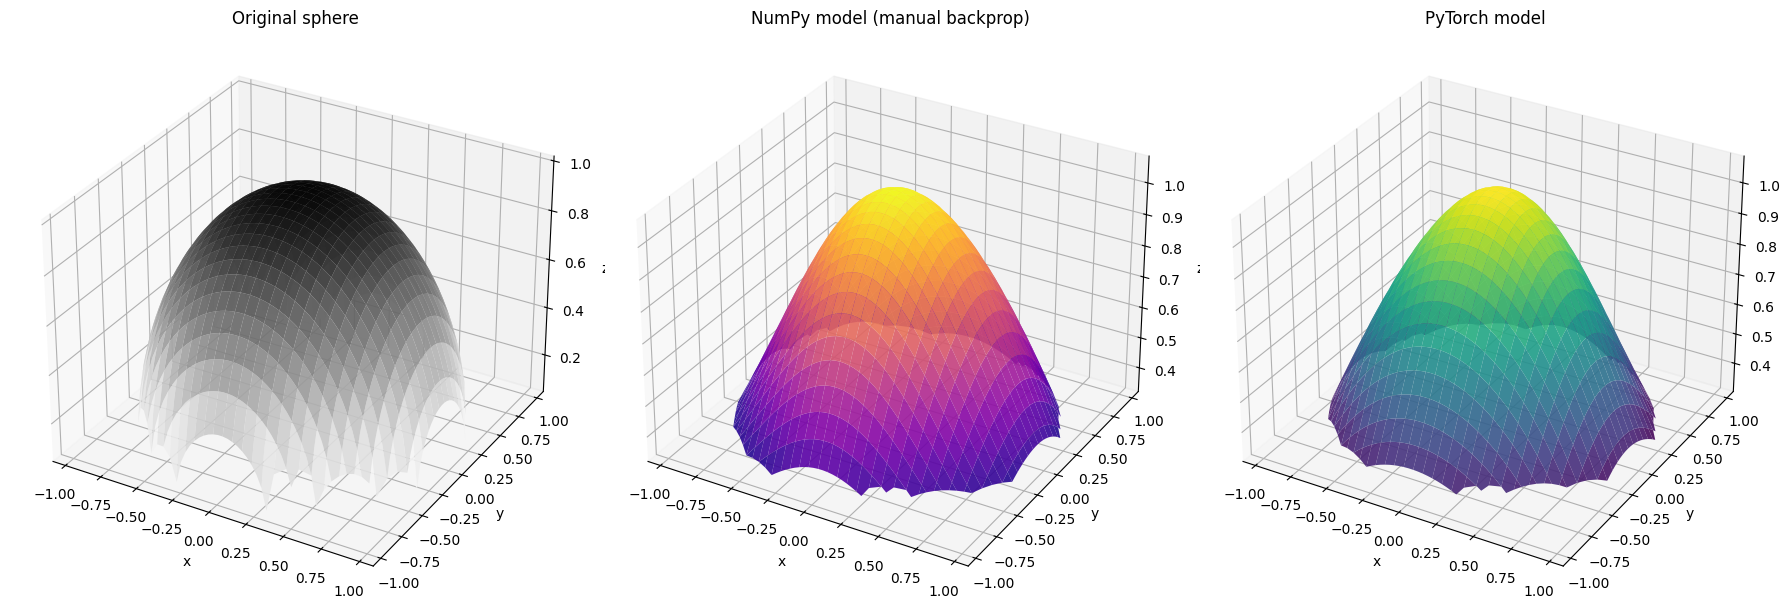

In [18]:
with torch.no_grad():
    grid_X_t = torch.tensor(grid_X, dtype=torch.float32)
    grid_Yhat_torch = model(grid_X_t).numpy().ravel()
grid_Yhat_torch[~mask] = np.nan
gz_pred_torch = grid_Yhat_torch.reshape(grid_n, grid_n)

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(gx, gy, gz_true, cmap='Greys', alpha=0.9)
ax1.set_title("Original sphere")
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(gx, gy, gz_pred, cmap='plasma', alpha=0.9)
ax2.set_title("NumPy model (manual backprop)")
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(gx, gy, gz_pred_torch, cmap='viridis', alpha=0.9)
ax3.set_title("PyTorch model")
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')

plt.tight_layout()
plt.show()